# 10.5.1 一步Bellman递推

## 学习目标与先修知识

从终端代价推导最优输入（input）与价值函数。

先修：第8.1章二次目标与梯度（gradient）、第3篇线性状态（state）转移和10.3反馈（feedback）。

In [ ]:
from systems_science.local_service import notebook_service_ready
notebook_service_ready()

## 具体问题

当前输入不仅影响这一刻的代价，还决定下一刻的状态。若只把本步输入压小，可能让终点偏离更严重。如何从终端条件向前计算“现在值得做什么”？

In [1]:
import math
import itertools
import ast
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()
BLUE, PINK, GREEN = "#008bfb", "#ff0051", "#00a56a"

## 初步实验

先用 x_next=x+u、阶段代价x²+u²、终端代价x_next²。对x=2试算u=0、−1、−2。

In [2]:
x=2.;print([(u,x*x+u*u+(x+u)**2) for u in [0.,-1.,-2.]])

[(0.0, 8.0), (-1.0, 6.0), (-2.0, 8.0)]


## 模型假设

有限一步标量模型（model） $x^+=ax+bu$，阶段代价 $qx^2+ru^2$，终端代价 $q_fx^{+2}$；r>0，q,qf≥0，输入无硬约束。价值函数表示当前状态下未来总成本的最小值，时间长度和终端条件必须公开。

## 数学解释与推导

有限时域的Bellman递推把“当前代价+剩余最优价值”最小化：
$$V_t(x)=\min_u\{qx^2+ru^2+V_{t+1}(ax+bu)\},\quad V_N(x)=q_fx^2.$$
对一步，展开可得 $J=qx^2+ru^2+q_f(a^2x^2+2abxu+b^2u^2)$。关于u的一阶条件为 $2(r+b^2q_f)u+2abq_fx=0$，因分母正，唯一最优输入
$$u^*=-\frac{abq_f}{r+b^2q_f}x.$$
代回得 $V(x)=Sx^2$，$S=q+a^2q_f-(abq_f)^2/(r+b^2q_f)$。当a=b=q=r=qf=1，$u^*=-x/2$、$S=3/2$。遗漏终端代价会给出u=0，回答的是另一个问题。

## 核心实现

将刚才推导的关系逐步写成函数。

In [3]:
def scalar_bellman(a, b, q, r, terminal, state):
    denominator = r + b * b * terminal
    gain = b * terminal * a / denominator
    value_weight = q + a * a * terminal - (a * b * terminal) ** 2 / denominator
    return -gain * state, value_weight * state * state, value_weight

## 对照实验

把代价作为u的函数画出来，再对不同终端权重显示解析最优输入与网格最小点。所有曲线使用同一当前状态。

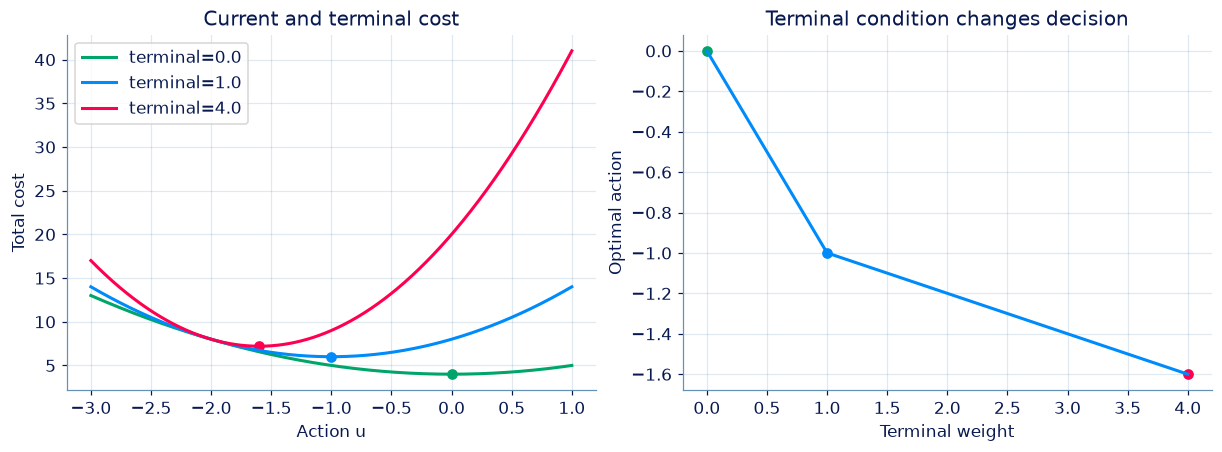

In [4]:
x=2.;actions=np.linspace(-3,1,801);fig,axes=plt.subplots(1,2,figsize=(11,4))
for terminal,color in [(0.,GREEN),(1.,BLUE),(4.,PINK)]:
    costs=x*x+actions**2+terminal*(x+actions)**2
    optimum,minimum,S=scalar_bellman(1.,1.,1.,1.,terminal,x)
    axes[0].plot(actions,costs,label=f'terminal={terminal}',color=color)
    axes[0].scatter([optimum],[minimum],color=color)
    axes[1].scatter([terminal],[optimum],color=color)
axes[0].set(xlabel='Action u',ylabel='Total cost',title='Current and terminal cost');axes[0].legend()
axes[1].plot([0,1,4],[scalar_bellman(1.,1.,1.,1.,v,x)[0] for v in [0,1,4]],color=BLUE)
axes[1].set(xlabel='Terminal weight',ylabel='Optimal action',title='Terminal condition changes decision');plt.show()

## 结果解释

终端权重为0时u=0；权重增大，当前决策更积极地移动下一状态。最佳输入和最低代价是同一个优化问题的两项结果。图中的网格只用于可视化，解析条件提供本例的精确参照。

### 独立核对

在细网格上直接计算所有候选成本并核对解析结果；对b=0的边界检查最优u=0。

In [5]:
for terminal in [0.,1.,4.]:
    u,cost,S=scalar_bellman(1.,1.,1.,1.,terminal,x)
    grid=np.linspace(-3,1,40001);direct=x*x+grid**2+terminal*(x+grid)**2
    np.testing.assert_allclose(cost,np.min(direct),atol=1e-8)
    assert abs(u-grid[np.argmin(direct)])<2e-4
assert scalar_bellman(.8,0.,2.,1.,3.,-1.)[0]==0.
print('解析Bellman与独立枚举及零输入作用边界一致。')

解析Bellman与独立枚举及零输入作用边界一致。


[在本章探索中改变条件](http://127.0.0.1:8000/chapters/10-05-%E5%8A%A8%E6%80%81%E8%A7%84%E5%88%92%E4%B8%8E%20LQR/explore/)：先预测结果，再比较图形与数值。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：一步二次价值

标量 x_next=a x+b u，当前代价 q x²+r u²、终端代价 qf x_next²。给定状态（state），返回最优输入（input）、最小总代价与价值系数S。

**函数与代码模板**

```python
def solve(
    a: float,
    b: float,
    q: float,
    r: float,
    terminal: float,
    state: float,
) -> tuple[float, float, float]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `a` | `float` | 状态保持系数。 | 1 |
| `b` | `float` | 输入作用系数。 | 状态/输入 |
| `q` | `float` | 当前状态权重，非负。 | 代价/状态² |
| `r` | `float` | 当前输入权重，严格正。 | 代价/输入² |
| `terminal` | `float` | 终端状态权重，非负。 | 代价/状态² |
| `state` | `float` | 当前状态。 | 状态单位 |

**返回值**

按以下顺序返回元组：(action, minimum_cost, value_weight)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `action` | `float` | 无约束最优输入。 | 输入单位 |
| `minimum_cost` | `float` | 从当前状态出发的最小总代价。 | 代价单位 |
| `value_weight` | `float` | 使V(x)=Sx²的S。 | 代价/状态² |

**计算规则**

展开 qx²+ru²+qf(ax+bu)²，对u配方；分母r+b²qf>0。

**约束与边界**

- 输入均为有限数；只需实现题定模型（model），不外推到真实病人或设备。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| a | 状态保持系数。 | 1 | 1 |
| b | 输入作用系数。 | 1 | 状态/输入 |
| q | 当前状态权重，非负。 | 1 | 代价/状态² |
| r | 当前输入权重，严格正。 | 1 | 代价/输入² |
| terminal | 终端状态权重，非负。 | 1 | 代价/状态² |
| state | 当前状态。 | 2 | 状态单位 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
a = 1.0
b = 1.0
q = 1.0
r = 1.0
terminal = 1.0
state = 2.0

result = solve(a, b, q, r, terminal, state)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| action | 无约束最优输入。 | -1 | 输入单位 |
| minimum_cost | 从当前状态出发的最小总代价。 | 6 | 代价单位 |
| value_weight | 使V(x)=Sx²的S。 | 1.5 | 代价/状态² |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = (-1.0, 6.0, 1.5)
```

**样例解释**

a=b=q=r=qf=1时 u*=−x/2，S=3/2；x=2给最优输入−1、代价6。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：一步二次价值](http://127.0.0.1:8000/chapters/10-05-%E5%8A%A8%E6%80%81%E8%A7%84%E5%88%92%E4%B8%8E%20LQR/practice/?question=p10-bellman-one)

### 第 2 题 · 单项选择题：遗漏终端代价

一步问题 x_next=x+u，阶段代价x²+u²，终端代价x_next²。x=2时哪项正确？

- **A.** 最优u=−1，总代价6。
- **B.** 最优u=0，因为只看本步输入（input）代价。
- **C.** 最优u=−2，总代价4。
- **D.** 未来价值与当前决策无关。

[作答：遗漏终端代价](http://127.0.0.1:8000/chapters/10-05-%E5%8A%A8%E6%80%81%E8%A7%84%E5%88%92%E4%B8%8E%20LQR/practice/?question=p10-terminal-matters)

### 第 3 题 · 单项选择题：Bellman 递推需要什么

有限时域动态规划中，V_t(x)代表从时刻t状态（state）x开始的最小剩余代价。哪项正确？

- **A.** 需要明确终端条件V_N。
- **B.** 每一步可用不同未来最优策略而不满足状态转移。
- **C.** 没有模型（model）也能直接写出精确递推。
- **D.** 最优决策完全不依赖当前状态。

[作答：Bellman 递推需要什么](http://127.0.0.1:8000/chapters/10-05-%E5%8A%A8%E6%80%81%E8%A7%84%E5%88%92%E4%B8%8E%20LQR/practice/?question=p10-bellman-scope)

### 第 4 题 · 单项选择题：代价权重与单位

将状态（state）数值单位改为原来的100倍，但不改变物理目标。应怎样处理 qx² 的权重？

- **A.** 相应调整q以保持同一物理代价。
- **B.** q永远不变。
- **C.** 只改绘图标签即可。
- **D.** 单位变化证明优化问题不可解。

[作答：代价权重与单位](http://127.0.0.1:8000/chapters/10-05-%E5%8A%A8%E6%80%81%E8%A7%84%E5%88%92%E4%B8%8E%20LQR/practice/?question=p10-weight-units)

**进一步阅读**

[MIT Underactuated Robotics：Linear Quadratic Regulators](https://underactuated.mit.edu/lqr.html)：动态规划、LQR 与有约束控制的边界；本教材的离散行动例由此处的教学目标独立设计。